# Simple Siamese Training

In [ ]:
import copy
from pathlib import Path
import torch
from torch import nn
from utils import set_seed, get_signature_paths, split_writers, sample_triplets, run_epoch, plot_history

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)
BATCH_SIZE = 16
EPOCHS = 10
MARGIN = 0.2
FORCE_RETRAIN = False

set_seed(SEED)
writers = get_signature_paths("dataset/process")
train_w, val_w, test_w = split_writers(writers, SEED)
print("Device:", DEVICE)
print("Train:", len(train_w), "Validation:", len(val_w), "Test:", len(test_w))

Device: cuda
Train: 40 Validation: 8 Test: 7


In [ ]:
NAME = "simple"
IMAGE_SIZE = (155, 220)
EMBEDDING_DIM = 64
CONFIG = {
    "image_size": list(IMAGE_SIZE), "embedding_dim": EMBEDDING_DIM,
    "seed": SEED, "train_w": train_w, "val_w": val_w, "test_w": test_w,
    "preprocessing": "otsu",
    "margin": MARGIN, "epochs": EPOCHS, "freeze_epochs": 0, "batch_size": BATCH_SIZE,
}

In [ ]:
def build_simple(image_size, embedding_dim):
    features = nn.Sequential(
        nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    )
    size = (image_size[0] // 8) * (image_size[1] // 8) * 64
    return nn.ModuleDict({"features": features, "head": nn.Linear(size, embedding_dim)})

model = build_simple(IMAGE_SIZE, EMBEDDING_DIM)
print(model)

ModuleDict(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Linear(in_features=32832, out_features=64, bias=True)
)


In [ ]:
if EPOCHS < 1:
    raise ValueError("EPOCHS must be positive.")
path = MODEL_DIR / f"{NAME}_embedding.pt"
model = model.to(DEVICE)

if path.is_file() and not FORCE_RETRAIN:
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=True)
    for key in ("image_size", "embedding_dim", "train_w", "val_w", "test_w", "preprocessing"):
        if checkpoint["config"].get(key) != CONFIG[key]:
            raise ValueError("Saved settings differ. Otsu preprocessing requires retraining. Set FORCE_RETRAIN = True.")
    model.load_state_dict(checkpoint["state_dict"])
    history = checkpoint["history"]
    print("Loaded saved model. Set FORCE_RETRAIN = True to train again.")
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    val_triplets = sample_triplets(writers, val_w, 32, SEED + 1)
    history = {"train": [], "validation": []}
    best_loss = float("inf")
    best_state = None
    waiting = 0
    for epoch in range(EPOCHS):
        triplets = sample_triplets(writers, train_w, 64, SEED + 10 + epoch)
        train_loss = run_epoch(model, NAME, triplets, CONFIG, DEVICE, optimizer)
        val_loss = run_epoch(model, NAME, val_triplets, CONFIG, DEVICE)
        history["train"].append(train_loss)
        history["validation"].append(val_loss)
        print(f"Epoch {epoch + 1} | Train: {train_loss:.4f} | Validation: {val_loss:.4f}")
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            waiting = 0
        else:
            waiting += 1
        if waiting >= 3:
            break
    if best_state is None:
        raise ValueError("Training did not produce a finite validation loss.")
    model.load_state_dict(best_state)
    torch.save({"name": NAME, "state_dict": best_state, "config": CONFIG, "history": history}, path)
    print("Saved:", path)
model.eval()

Epoch 1 | Train: 0.1201 | Validation: 0.2057
Epoch 2 | Train: 0.0341 | Validation: 0.1601
Epoch 3 | Train: 0.0144 | Validation: 0.1689
Epoch 4 | Train: 0.0074 | Validation: 0.1610
Epoch 5 | Train: 0.0033 | Validation: 0.1655
Saved: model\simple_embedding.pt


ModuleDict(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Linear(in_features=32832, out_features=64, bias=True)
)

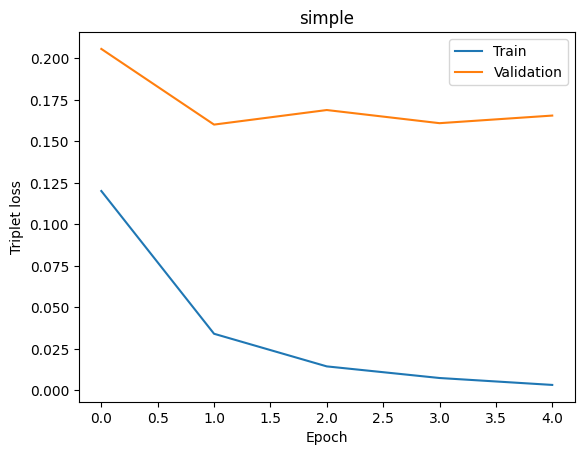

In [ ]:
plot_history(history, NAME)